# Mengamati Kualitas Udara Sumenep

# Crawling Data:


Proses *crawling* (pengumpulan) data ini mengambil data kualitas udara dari satelit Sentinel-5P melalui layanan Copernicus Data Space[cite: 1]. Berikut adalah rincian ekstraksi datanya:
* **Lokasi Observasi**: Area observasi difokuskan pada wilayah Kabupaten Sumenep, Provinsi Jawa Timur[cite: 1]. Titik koordinat poligon area meliputi wilayah dari bujur 113.738 hingga 113.910 dan lintang -7.060 hingga -6.965[cite: 1].
* **Periode Pengambilan Data**: Data ditarik untuk periode 1 tahun, terhitung dari tanggal 24 Agustus 2025 hingga 24 Agustus 2026[cite: 1].
* **Total Data**: Proses ekstraksi menghasilkan total 365 hari pengamatan harian untuk dianalisis[cite: 1].



## Business Understanding

### Mengamati Kualitas Udara

[Deskripsikan apa itu indeks kualitas Udara (air quality index]


[Jelaskan unsur-unsur yang menyebabkan baik/buruknya kualitas Udara (polutan)]

Unsur:
- NO2
- CO
- CH4
- SO2

## Data Understanding

### Mengamati Kualitas Udara

**Indeks Kualitas Udara (Air Quality Index / AQI)**
Indeks Kualitas Udara (AQI) adalah ukuran atau indikator yang digunakan secara global untuk melaporkan seberapa bersih atau tercemarnya udara harian di suatu area. AQI berfokus pada dampak kesehatan yang mungkin dialami masyarakat dalam beberapa jam atau hari setelah menghirup udara yang berpolusi. Semakin tinggi nilai AQI, semakin tinggi tingkat polusi udara, yang berarti bahaya kesehatan bagi manusia dan makhluk hidup lainnya juga semakin besar.

**Unsur-Unsur Polutan Kualitas Udara**
Kualitas udara yang buruk disebabkan oleh penumpukan gas dan partikel berbahaya di atmosfer. Dalam program ini, terdapat 4 unsur polutan utama yang diamati[cite: 1]:
* **NO2 (Nitrogen Dioksida)**: Dalam program ini, NO2 adalah salah satu unsur gas yang diekstraksi[cite: 1]. NO2 adalah gas beracun yang sebagian besar terbentuk dari emisi pembakaran bahan bakar fosil seperti knalpot kendaraan dan aktivitas pabrik. Paparan jangka panjang dapat mengiritasi saluran pernapasan.
* **CO (Karbon Monoksida)**: Program ini juga mengumpulkan data konsentrasi gas CO[cite: 1]. Gas tidak berwarna dan tidak berbau ini dihasilkan oleh pembakaran yang tidak sempurna dari kendaraan bermotor maupun mesin industri. Gas ini berbahaya karena dapat menghambat peredaran oksigen dalam darah.
* **CH4 (Metana)**: Gas metana (CH4) termasuk dalam polutan yang dianalisis di sini[cite: 1]. Metana merupakan gas rumah kaca kuat yang mempercepat pemanasan global, seringkali bersumber dari aktivitas agrikultur, peternakan, serta tempat pembuangan limbah.
* **SO2 (Sulfur Dioksida)**: Konsentrasi SO2 ikut ditarik dari data satelit[cite: 1]. Gas berbau menyengat ini umumnya dilepaskan selama pembakaran batu bara dan minyak bumi di pembangkit listrik, pabrik peleburan logam, serta dari aktivitas alam seperti letusan gunung berapi.

In [ ]:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=RCBA-QPMP 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.7393608, -6.9664964],
            [113.9108166, -6.9658665],
            [113.9026602, -7.0601733],
            [113.7386148, -7.0585753],
            [113.7393608, -6.9664964]
        ]
    ]
}

start_date = "2025-08-24"
end_date = "2026-08-24"

gases = ["NO2", "CO", "CH4", "SO2"]

for gas in gases:
    print(f"Mulai memproses gas: {gas}")

    s5post = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[start_date, end_date],
        spatial_extent=aoi,
        bands=[gas],
    )

    s5p_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

    job_title = f"{gas}_Sumenep_1Tahun"
    output_filename = f"{gas}_Sumenep_1Tahun.nc"

    try:
        job = s5p_daily.execute_batch(
            title=job_title,
            outputfile=output_filename
        )
        print(f"Berhasil! File tersimpan sebagai: {output_filename}\n")
    except Exception as e:
        print(f"Gagal memproses {gas}. Error: {e}\n")

Mulai memproses gas: NO2
0:00:00 Job 'j-2608301522174f329b5bc484c7cc7e1e': send 'start'
0:00:02 Job 'j-2608301522174f329b5bc484c7cc7e1e': queued (progress 0%)
0:00:07 Job 'j-2608301522174f329b5bc484c7cc7e1e': queued (progress 0%)
0:00:14 Job 'j-2608301522174f329b5bc484c7cc7e1e': queued (progress 0%)
0:00:22 Job 'j-2608301522174f329b5bc484c7cc7e1e': queued (progress 0%)
0:00:32 Job 'j-2608301522174f329b5bc484c7cc7e1e': queued (progress 0%)
0:00:44 Job 'j-2608301522174f329b5bc484c7cc7e1e': queued (progress 0%)
0:01:00 Job 'j-2608301522174f329b5bc484c7cc7e1e': running (progress N/A)
0:01:19 Job 'j-2608301522174f329b5bc484c7cc7e1e': running (progress N/A)
0:01:43 Job 'j-2608301522174f329b5bc484c7cc7e1e': running (progress N/A)
0:02:13 Job 'j-2608301522174f329b5bc484c7cc7e1e': running (progress N/A)
0:02:51 Job 'j-2608301522174f329b5bc484c7cc7e1e': running (progress N/A)
0:03:37 Job 'j-2608301522174f329b5bc484c7cc7e1e': running (progress N/A)
0:04:36 Job 'j-2608301522174f329b5bc484c7cc7e1e'

In [ ]:
!pip install netCDF4

In [ ]:
import netCDF4
import os
import numpy as np
import pandas as pd
from functools import reduce

gases = ["NO2", "CO", "CH4", "SO2"]
dataframes = []

for gas in gases:
    file_path = f"{gas}_Sumenep_1Tahun.nc"

    if not os.path.exists(file_path):
        print(f"File {file_path} tidak ditemukan. Lewati...")
        continue

    ds = netCDF4.Dataset(file_path)
    available_vars = ds.variables.keys()

    time_col = "t" if "t" in available_vars else ("time" if "time" in available_vars else None)

    if time_col:
        time_var = ds.variables[time_col]
        try:
            dates = netCDF4.num2date(time_var[:], units=time_var.units)
            dates = pd.to_datetime([d.strftime('%Y-%m-%d') for d in dates])
        except Exception:
            dates = pd.to_datetime(time_var[:])
    else:
        print(f"Variabel waktu tidak ditemukan di {file_path}!")
        ds.close()
        continue

    if gas in available_vars:
        data = ds.variables[gas][:]
        mean_data = np.mean(data, axis=(1, 2))

        df_temp = pd.DataFrame({'Tanggal': dates, gas: mean_data})
        dataframes.append(df_temp)

    ds.close()

if dataframes:
    df_merged = reduce(lambda left, right: pd.merge(left, right, on='Tanggal', how='outer'), dataframes)

    df_merged = df_merged.sort_values('Tanggal').reset_index(drop=True)

    start_date = "2025-08-24"
    end_date = "2026-08-24"

    mask = (df_merged['Tanggal'] >= start_date) & (df_merged['Tanggal'] <= end_date)
    df_filtered = df_merged.loc[mask].reset_index(drop=True)

    print(f"\n Menampilkan Data Kualitas Udara ({start_date} s/d {end_date})")
    print("=" * 65)
    print(df_filtered.head(10))
    print("...")
    print(df_filtered.tail(5))
    print("=" * 65)
    print(f"Total hari pengamatan yang ditemukan: {len(df_filtered)} hari.")

else:
    print("Tidak ada data yang berhasil diproses.")


 Menampilkan Data Kualitas Udara (2025-08-24 s/d 2026-08-24)
     Tanggal       NO2        CO          CH4       SO2
0 2025-08-24  0.000017  0.018958          NaN  0.000054
1 2025-08-25  0.000018  0.028619  1876.476318 -0.000049
2 2025-08-26  0.000006       NaN          NaN  0.000003
3 2025-08-27  0.000020  0.025029  1813.483398  0.000029
4 2025-08-28  0.000007  0.024825  1881.046549  0.000099
5 2025-08-29  0.000012  0.026020  1882.000217  0.000023
6 2025-08-30  0.000021  0.022508  1891.446289 -0.000002
7 2025-08-31  0.000009  0.026791          NaN -0.000019
8 2025-09-01  0.000006  0.023771          NaN -0.000137
9 2025-09-02  0.000006  0.025578          NaN  0.000069
...
       Tanggal       NO2        CO          CH4       SO2
360 2026-08-19  0.000011  0.025153          NaN -0.000075
361 2026-08-20  0.000010  0.027507          NaN  0.000061
362 2026-08-21  0.000016  0.025031  1747.230225  0.000104
363 2026-08-22  0.000009  0.028222  1871.480957 -0.000013
364 2026-08-23  0.000009  0.

### Eksplorasi Data

#### visualisasi data peta

- Titik Pusat Peta: Program mengambil daftar titik koordinat batas wilayah observasi, lalu menghitung nilai rata-rata lintang dan bujur untuk dijadikan titik fokus tengah peta.  
- Pemetaan Poligon: Menggunakan library folium, program merender peta dasar interaktif dari OpenStreetMap.

In [ ]:
import folium
lats = [coord[1] for coord in aoi["coordinates"][0]]
lons = [coord[0] for coord in aoi["coordinates"][0]]
center_lat = sum(lats) / len(lats)
center_lon = sum(lons) / len(lons)

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='OpenStreetMap')

folium_coords = [[coord[1], coord[0]] for coord in aoi["coordinates"][0]]

folium.Polygon(
    locations=folium_coords,
    color='red',
    weight=3,
    fill=True,
    fill_color='blue',
    fill_opacity=0.2,
    tooltip='Area Observasi (Sumenep)'
).add_to(m)

m

#### Deteksi dan Penanganan Missing Value
- Identifikasi: Program mendeteksi sel data yang kosong menggunakan isna().sum() dan menampilkan persentase kerusakannya. Kekosongan ini wajar terjadi pada data satelit, umumnya akibat gangguan cuaca atau tutupan awan saat citra diambil.  
- Interpolasi Linear: Untuk mengatasi celah tersebut tanpa membuang data, program menggunakan teknik interpolasi linear (interpolate(method='linear')). Metode ini mengisi nilai yang hilang dengan menarik garis lurus secara matematis antara titik data sebelum dan sesudahnya.  
- Pelengkapan Ekstrem: Fungsi pelengkap bfill() dan ffill() ditambahkan untuk memastikan tidak ada celah tersisa di ujung awal atau akhir hari observasi.  

In [46]:
import pandas as pd
import numpy as np

print("1. IDENTIFIKASI MISSING VALUE")
print("-" * 40)
missing_count = df_filtered.isna().sum()
print(missing_count)

missing_percentage = (missing_count / len(df_filtered)) * 100
print("\nPersentase Missing Value (%):")
print(missing_percentage.round(2))
print("\n")


print("2. MENANGANI MISSING VALUE")
print("-" * 40)

df_dropped = df_filtered.dropna()

df_mean = df_filtered.copy()
gases = ["NO2", "CO", "CH4", "SO2"]
for gas in gases:
    if gas in df_mean.columns:
        mean_value = df_mean[gas].mean()
        df_mean[gas] = df_mean[gas].fillna(mean_value)

df_interpolated = df_filtered.copy()
df_interpolated[gases] = df_interpolated[gases].interpolate(method='linear')

df_interpolated = df_interpolated.bfill().ffill()

print("Cek kembali Missing Value setelah menggunakan Interpolasi:")
print(df_interpolated.isna().sum())

1. IDENTIFIKASI MISSING VALUE
----------------------------------------
Tanggal      0
NO2        130
CO         129
CH4        319
SO2         97
dtype: int64

Persentase Missing Value (%):
Tanggal     0.00
NO2        35.62
CO         35.34
CH4        87.40
SO2        26.58
dtype: float64


2. MENANGANI MISSING VALUE
----------------------------------------
Cek kembali Missing Value setelah menggunakan Interpolasi:
Tanggal    0
NO2        0
CO         0
CH4        0
SO2        0
dtype: int64


#### Membersihkan Noise
- Konsep Filter: Data harian polusi biasanya memiliki noise berupa lonjakan tajam sesaat. Program menerapkan teknik Simple Moving Average (SMA) dan Filter Median.  
- Jendela 7 Hari: Fungsi .rolling(window=7).mean() menghitung rata-rata bergerak menggunakan rentang waktu 7 hari. Dengan merata-ratakan nilai selama sepekan, garis grafik menjadi lebih halus sehingga tren utama kualitas udara lebih mudah dianalisis secara visual.

In [47]:
import pandas as pd
import numpy as np

df_smoothed = df_interpolated.copy()
gases = ["NO2", "CO", "CH4", "SO2"]

window_size = 7

print("MENERAPKAN SMOOTHING UNTUK MENGURANGI NOISE")
print("-" * 50)

for gas in gases:
    if gas in df_smoothed.columns:
        df_smoothed[f"{gas}_SMA"] = df_smoothed[gas].rolling(window=window_size, min_periods=1).mean()

for gas in gases:
    if gas in df_smoothed.columns:
        df_smoothed[f"{gas}_Median"] = df_smoothed[gas].rolling(window=window_size, min_periods=1).median()

print("Perbandingan Data NO2 Asli vs Smoothing:")
print(df_smoothed[['Tanggal', 'NO2', 'NO2_SMA', 'NO2_Median']].head(10))

MENERAPKAN SMOOTHING UNTUK MENGURANGI NOISE
--------------------------------------------------
Perbandingan Data NO2 Asli vs Smoothing:
     Tanggal       NO2   NO2_SMA  NO2_Median
0 2025-08-24  0.000017  0.000017    0.000017
1 2025-08-25  0.000018  0.000017    0.000017
2 2025-08-26  0.000006  0.000014    0.000017
3 2025-08-27  0.000020  0.000015    0.000017
4 2025-08-28  0.000007  0.000014    0.000017
5 2025-08-29  0.000012  0.000013    0.000014
6 2025-08-30  0.000021  0.000014    0.000017
7 2025-08-31  0.000009  0.000013    0.000012
8 2025-09-01  0.000006  0.000011    0.000009
9 2025-09-02  0.000006  0.000011    0.000009


#### Membuat dan menampilkan Grafik

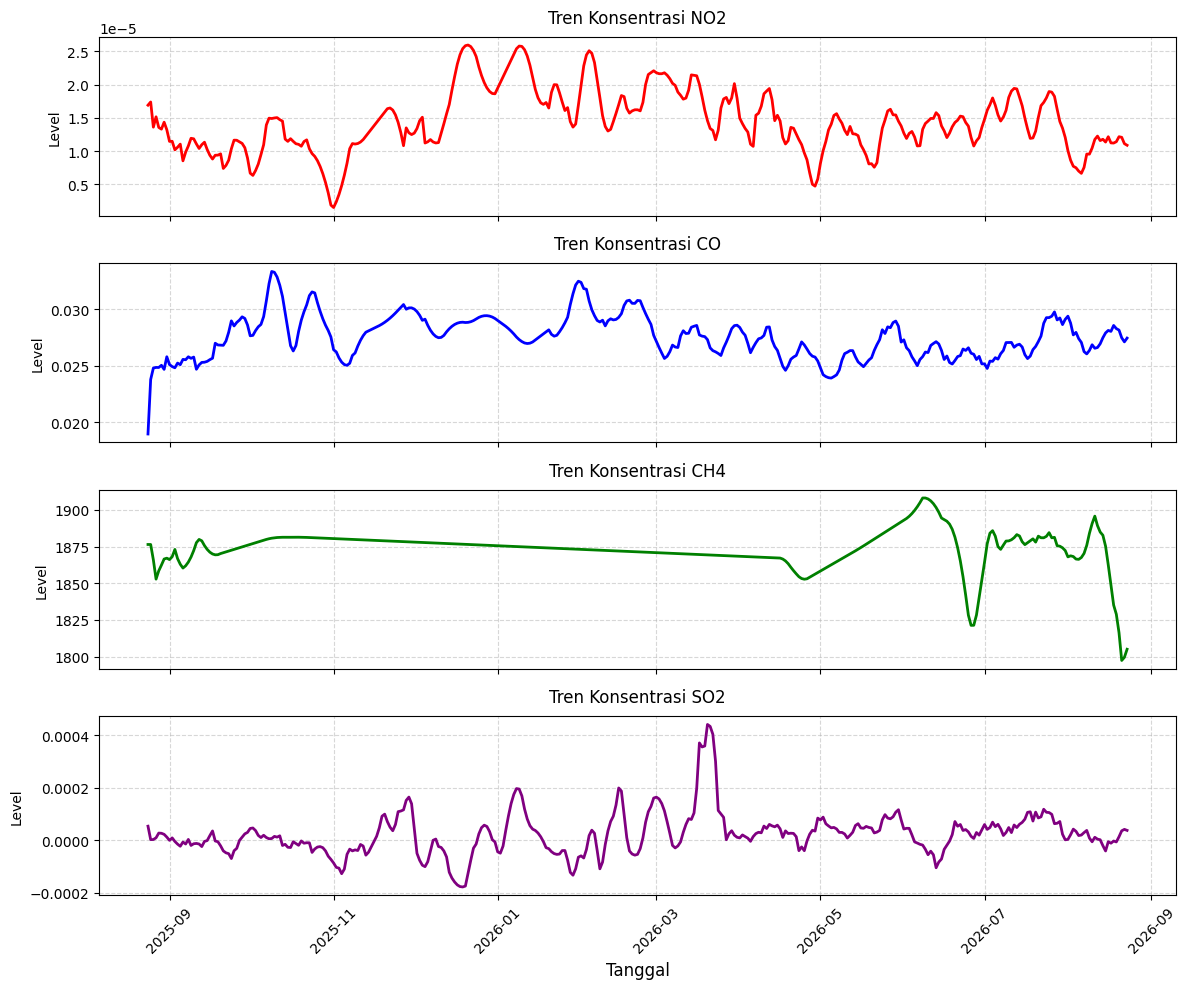

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

colors = {"NO2": "red", "CO": "blue", "CH4": "green", "SO2": "purple"}
gases = ["NO2", "CO", "CH4", "SO2"]

for i, gas in enumerate(gases):
    sma_column = f"{gas}_SMA"
    if sma_column in df_smoothed.columns:
        axes[i].plot(df_smoothed['Tanggal'], df_smoothed[sma_column],
                     color=colors[gas], linewidth=2)

        axes[i].set_title(f'Tren Konsentrasi {gas}', fontsize=12, pad=10)
        axes[i].set_ylabel('Level')
        axes[i].grid(True, linestyle='--', alpha=0.5)

axes[3].set_xlabel('Tanggal', fontsize=12)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

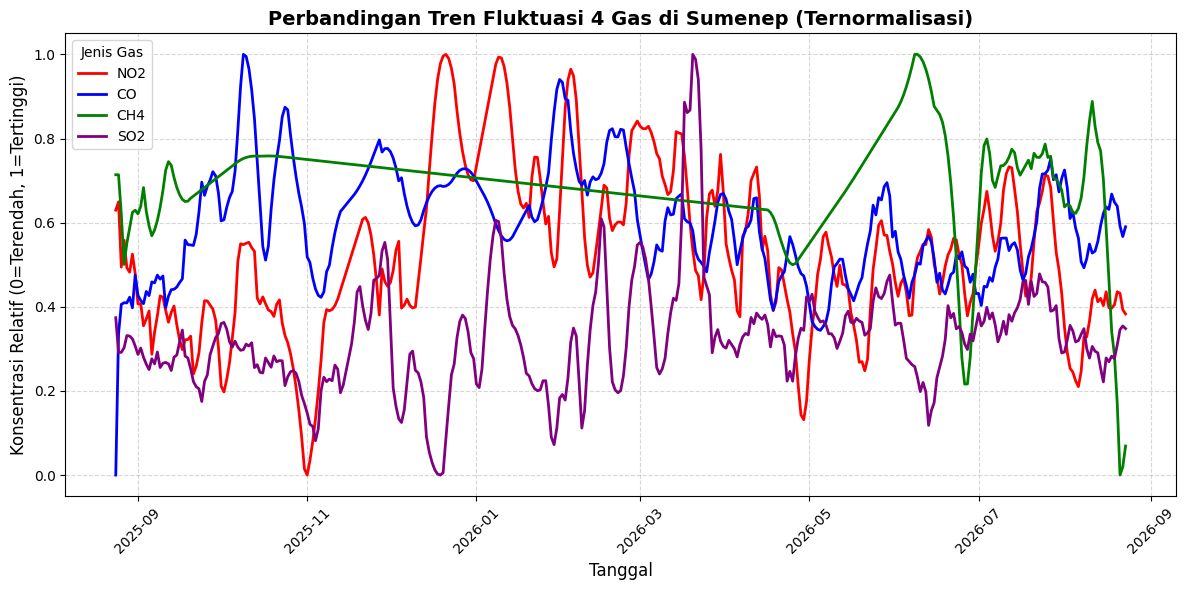

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_normalized = df_smoothed.copy()
gases = ["NO2", "CO", "CH4", "SO2"]
colors = {"NO2": "red", "CO": "blue", "CH4": "green", "SO2": "purple"}

for gas in gases:
    sma_column = f"{gas}_SMA"
    if sma_column in df_normalized.columns:
        min_val = df_normalized[sma_column].min()
        max_val = df_normalized[sma_column].max()
        df_normalized[f"{gas}_Norm"] = (df_normalized[sma_column] - min_val) / (max_val - min_val)

fig, ax = plt.subplots(figsize=(12, 6))

for gas in gases:
    norm_column = f"{gas}_Norm"
    if norm_column in df_normalized.columns:
        ax.plot(df_normalized['Tanggal'], df_normalized[norm_column],
                color=colors[gas], label=gas, linewidth=2)

ax.set_xlabel('Tanggal', fontsize=12)
ax.set_ylabel('Konsentrasi Relatif (0=Terendah, 1=Tertinggi)', fontsize=12)
plt.title('Perbandingan Tren Fluktuasi 4 Gas di Sumenep (Ternormalisasi)', fontsize=14, fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.legend(loc='upper left', title="Jenis Gas")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()